# Worksheet 7 -- Neural Networks-I

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
spectra = np.load("spectrums.npy")
print("Spectra array shape:", spectra.shape)

Spectra array shape: (41423, 52, 4)


In [37]:
wave_grid = spectra[:, :, 0]
spectrum = spectra[:, :, 1]
uncertainty = spectra[:, :, 2]
bin_width = spectra[:, :, 3]

In [38]:
# Is the same for each spectrum.
wg = wave_grid[0]
len(spectrum)

41423

In [39]:
print(f"Transit depth range: {spectrum.min():.1f} to {spectrum.max():.1f} ppm")
print(f"Mean uncertainty: {uncertainty.mean()} ppm")

Transit depth range: 0.0 to 0.1 ppm
Mean uncertainty: 7.32740691956432e-05 ppm


0 4.3


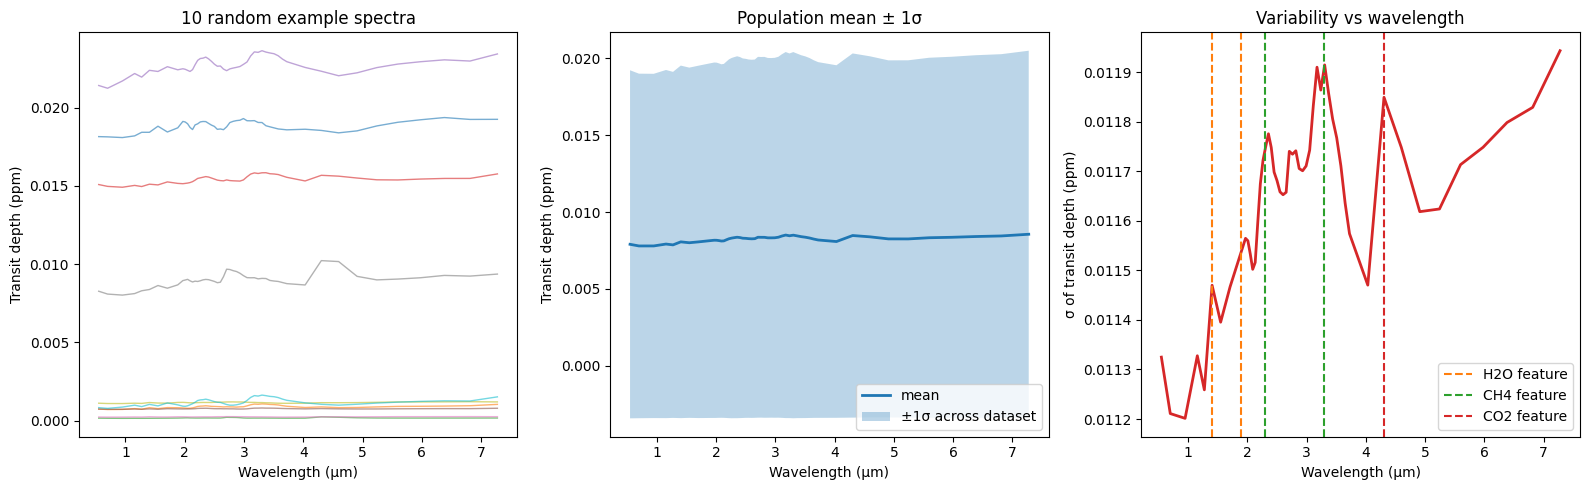

In [ ]:
# Randomly chosen spectra
spec_idx = [100, 567, 10777, 23456, 37076, 40235, 19283, 856, 7451, 8254]
lines_info = {
    "H2O": {"wavelengths": [1.4, 1.9], "color": "C1"},
    "CH4": {"wavelengths": [2.3, 3.3], "color": "C2"},
    "CO2": {"wavelengths": [4.3], "color": "C3"}
}

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for i in spec_idx:
    ax[0].plot(wg, spectrum[i], label=f"Spectrum {i}", alpha=0.6, lw=1)
ax[0].set_xlabel("Wavelength (µm)")
ax[0].set_ylabel("Transit depth (ppm)")
ax[0].set_title("10 random example spectra")

mean_spec = spectrum.mean(axis=0)
std_spec = spectrum.std(axis=0)
ax[1].plot(wg, mean_spec, color="C0", lw=2, label="mean")
ax[1].fill_between(wg, mean_spec - std_spec, mean_spec + std_spec, alpha=0.3, label="±1σ across dataset")
ax[1].set_xlabel("Wavelength (µm)")
ax[1].set_ylabel("Transit depth (ppm)")
ax[1].set_title("Population mean ± 1σ")
ax[1].legend()

ax[2].plot(wg, std_spec, color="C3", lw=2)
for compound, info in lines_info.items():
    for j, wavelength in enumerate(info["wavelengths"]):
        label = f"{compound} feature" if j == 0 else None
        ax[2].axvline(wavelength, color=info["color"], ls="--", label=label)
ax[2].set_xlabel("Wavelength (µm)")
ax[2].set_ylabel("σ of transit depth (ppm)")
ax[2].set_title("Variability vs wavelength")
ax[2].legend()


plt.tight_layout()